In [1]:
import pandas as pd

# 1. Load all 6 original CSV files
users_df = pd.read_csv('users.csv')
movies_df = pd.read_csv('movies.csv')
watch_df = pd.read_csv('watch_history.csv')
search_df = pd.read_csv('search_logs.csv')
rec_df = pd.read_csv('recommendation_logs.csv')
reviews_df = pd.read_csv('reviews.csv')

# 2. Print the shape of each dataset to understand its size
print("📋 --- Dataset Dimensions (Shapes) ---")
print("Users shape:           ", users_df.shape)
print("Movies shape:          ", movies_df.shape)
print("Watch History shape:   ", watch_df.shape)
print("Search Logs shape:     ", search_df.shape)
print("Recommendation shape:  ", rec_df.shape)
print("Reviews shape:         ", reviews_df.shape)
print("\n" + "="*40 + "\n")

# 3. Check the number of duplicate rows in each dataset
print("⚠️ --- Duplicate Rows Count ---")
print("Users duplicates:      ", users_df.duplicated().sum())
print("Movies duplicates:     ", movies_df.duplicated().sum())
print("Watch History duplicates:", watch_df.duplicated().sum())
print("Search Logs duplicates: ", search_df.duplicated().sum())
print("Recommendation dups:   ", rec_df.duplicated().sum())
print("Reviews duplicates:    ", reviews_df.duplicated().sum())

📋 --- Dataset Dimensions (Shapes) ---
Users shape:            (10300, 16)
Movies shape:           (1040, 18)
Watch History shape:    (105000, 12)
Search Logs shape:      (26500, 11)
Recommendation shape:   (52000, 11)
Reviews shape:          (15450, 12)


⚠️ --- Duplicate Rows Count ---
Users duplicates:       300
Movies duplicates:      40
Watch History duplicates: 5000
Search Logs duplicates:  1500
Recommendation dups:    2000
Reviews duplicates:     450


In [5]:
# Remove duplicate rows from all 6 dataframes
# Add .copy() at the end of each line to create a completely separate copy in memory.
users_clean = users_df.drop_duplicates().copy()
movies_clean = movies_df.drop_duplicates().copy()
watch_clean = watch_df.drop_duplicates().copy()
search_clean = search_df.drop_duplicates().copy()
rec_clean = rec_df.drop_duplicates().copy()
reviews_clean = reviews_df.drop_duplicates().copy()

# Verify the new shapes after duplicate removal
print("✅ --- New Dataset Dimensions After Removing Duplicates ---")
print("Cleaned Users shape:          ", users_clean.shape)
print("Cleaned Movies shape:         ", movies_clean.shape)
print("Cleaned Watch History shape:  ", watch_clean.shape)
print("Cleaned Search Logs shape:    ", search_clean.shape)
print("Cleaned Recommendation shape: ", rec_clean.shape)
print("Cleaned Reviews shape:        ", reviews_clean.shape)

✅ --- New Dataset Dimensions After Removing Duplicates ---
Cleaned Users shape:           (10000, 16)
Cleaned Movies shape:          (1000, 18)
Cleaned Watch History shape:   (100000, 12)
Cleaned Search Logs shape:     (25000, 11)
Cleaned Recommendation shape:  (50000, 11)
Cleaned Reviews shape:         (15000, 12)


In [6]:
# Check for missing values in all dataframes
print("🔍 --- Missing Values Count Per Dataset ---")

print("\n👥 Users Missing Values:")
print(users_clean.isnull().sum()[users_clean.isnull().sum() > 0])

print("\n🎬 Movies Missing Values:")
print(movies_clean.isnull().sum()[movies_clean.isnull().sum() > 0])

print("\n👁️ Watch History Missing Values:")
print(watch_clean.isnull().sum()[watch_clean.isnull().sum() > 0])

print("\n🔍 Search Logs Missing Values:")
print(search_clean.isnull().sum()[search_clean.isnull().sum() > 0])

print("\n🤖 Recommendation Logs Missing Values:")
print(rec_clean.isnull().sum()[rec_clean.isnull().sum() > 0])

print("\n⭐ Reviews Missing Values:")
print(reviews_clean.isnull().sum()[reviews_clean.isnull().sum() > 0])

🔍 --- Missing Values Count Per Dataset ---

👥 Users Missing Values:
age               1194
gender             800
monthly_spend      993
household_size    1500
dtype: int64

🎬 Movies Missing Values:
genre_secondary       643
imdb_rating           144
production_budget     647
box_office_revenue    678
number_of_seasons     725
number_of_episodes    695
dtype: int64

👁️ Watch History Missing Values:
watch_duration_minutes    11771
progress_percentage        8094
user_rating               79886
dtype: int64

🔍 Search Logs Missing Values:
clicked_result_position    12771
search_duration_seconds     1215
dtype: int64

🤖 Recommendation Logs Missing Values:
recommendation_score    5005
algorithm_version       2522
dtype: int64

⭐ Reviews Missing Values:
helpful_votes      1757
total_votes        1757
review_text         767
sentiment_score    1177
dtype: int64


In [7]:
# =====================================================================
# DATA CLEANING STAGE 2: HANDLING MISSING VALUES (IMPUTATION)
# =====================================================================

# --- 1. CLEANING USERS DATASET ---
# Fill missing age with the median age
users_clean['age'] = users_clean['age'].fillna(users_clean['age'].median())

# Fill missing gender with 'Unknown'
users_clean['gender'] = users_clean['gender'].fillna('Unknown')

# Fill missing monthly spend with its median
users_clean['monthly_spend'] = users_clean['monthly_spend'].fillna(users_clean['monthly_spend'].median())

# Fill missing household size with the median value
users_clean['household_size'] = users_clean['household_size'].fillna(users_clean['household_size'].median())


# --- 2. CLEANING WATCH HISTORY DATASET ---
# Fill missing watch duration with the mean or median duration
watch_clean['watch_duration_minutes'] = watch_clean['watch_duration_minutes'].fillna(watch_clean['watch_duration_minutes'].median())

# Fill missing progress percentage with the median progress
watch_clean['progress_percentage'] = watch_clean['progress_percentage'].fillna(watch_clean['progress_percentage'].median())

# For user_rating, use -1 as a placeholder meaning "User did not rate this content"
watch_clean['user_rating'] = watch_clean['user_rating'].fillna(-1)


# --- 3. CLEANING SEARCH LOGS DATASET ---
# Missing search duration filled with the median search time
search_clean['search_duration_seconds'] = search_clean['search_duration_seconds'].fillna(search_clean['search_duration_seconds'].median())

# For clicked_result_position, use -1 meaning "User searched but did not click any results"
search_clean['clicked_result_position'] = search_clean['clicked_result_position'].fillna(-1)


# --- 4. CLEANING RECOMMENDATION LOGS DATASET ---
# Fill missing recommendation score with its median
rec_clean['recommendation_score'] = rec_clean['recommendation_score'].fillna(rec_clean['recommendation_score'].median())

# Fill missing algorithm version with 'Unknown'
rec_clean['algorithm_version'] = rec_clean['algorithm_version'].fillna('Unknown')


# --- 5. CLEANING REVIEWS DATASET ---
# Fill missing votes with 0 (meaning a new review with no votes yet)
reviews_clean['helpful_votes'] = reviews_clean['helpful_votes'].fillna(0)
reviews_clean['total_votes'] = reviews_clean['total_votes'].fillna(0)

# Fill missing review text with a placeholder
reviews_clean['review_text'] = reviews_clean['review_text'].fillna('No Review Text Provided')

# Fill missing sentiment scores with the mean sentiment score
reviews_clean['sentiment_score'] = reviews_clean['sentiment_score'].fillna(reviews_clean['sentiment_score'].mean())


# --- VERIFICATION BLOCK ---
# Write a quick print statement to check if your missing values are gone
print("Remaining missing values in Users:", users_clean['age'].isnull().sum())
print("Remaining missing values in Watch History:", watch_clean['watch_duration_minutes'].isnull().sum())
print("Remaining missing values in Search Logs:", search_clean['search_duration_seconds'].isnull().sum())

Remaining missing values in Users: 0
Remaining missing values in Watch History: 0
Remaining missing values in Search Logs: 0


In [8]:
# 1. Check for extreme or impossible ages
print("📊 Outlier Check - Age Column:")
print("Minimum age in data: ", users_clean['age'].min())
print("Maximum age in data: ", users_clean['age'].max())
print("Number of users under 10 years old: ", (users_clean['age'] < 10).sum())
print("Number of users over 85 years old:  ", (users_clean['age'] > 85).sum())
print("-" * 50)

# 2. Check for extreme monthly spend
print("📊 Outlier Check - Monthly Spend Column:")
print("Minimum spend: ", users_clean['monthly_spend'].min())
print("Maximum spend: ", users_clean['monthly_spend'].max())
print("Number of users spending more than $50/month: ", (users_clean['monthly_spend'] > 50).sum())

📊 Outlier Check - Age Column:
Minimum age in data:  -7.0
Maximum age in data:  109.0
Number of users under 10 years old:  164
Number of users over 85 years old:   25
--------------------------------------------------
📊 Outlier Check - Monthly Spend Column:
Minimum spend:  0.11
Maximum spend:  997.8
Number of users spending more than $50/month:  212


In [9]:
# =====================================================================
# DATA CLEANING STAGE 3: HANDLING OUTLIERS (CAPPING & IMPUTATION)
# =====================================================================

# 1. Calculate the median values for Age and Monthly Spend
median_age = users_clean['age'].median()
median_spend = users_clean['monthly_spend'].median()

# 2. Fix Age Outliers: Replace ages < 10 or > 85 with the median age
users_clean.loc[(users_clean['age'] < 10) | (users_clean['age'] > 85), 'age'] = median_age

# 3. Fix Monthly Spend Outliers: Replace spends > $50 with the median spend
users_clean.loc[users_clean['monthly_spend'] > 50, 'monthly_spend'] = median_spend

# --- VERIFICATION BLOCK ---
# Re-check the min and max values to ensure outliers are handled
print("✅ Outliers handled successfully!")
print("New Minimum age: ", users_clean['age'].min())
print("New Maximum age: ", users_clean['age'].max())
print("New Maximum spend: $", users_clean['monthly_spend'].max())

✅ Outliers handled successfully!
New Minimum age:  10.0
New Maximum age:  79.0
New Maximum spend: $ 49.96


In [10]:
# =====================================================================
# DATA CLEANING STAGE 4: DATETIME FORMATTING
# =====================================================================

# 1. Convert dates in Users dataset
users_clean['subscription_start_date'] = pd.to_datetime(users_clean['subscription_start_date'])

# 2. Convert dates in Watch History dataset
watch_clean['watch_date'] = pd.to_datetime(watch_clean['watch_date'])

# 3. Convert dates in Search Logs dataset
search_clean['search_date'] = pd.to_datetime(search_clean['search_date'])

# 4. Convert dates in Recommendation Logs dataset
rec_clean['recommendation_date'] = pd.to_datetime(rec_clean['recommendation_date'])

# 5. Convert dates in Reviews dataset
reviews_clean['review_date'] = pd.to_datetime(reviews_clean['review_date'])

# --- VERIFICATION BLOCK ---
# Check the data types (dtypes) to ensure they are now datetime
print("✅ Datetime conversion complete!")
print("Users Date Type:         ", users_clean['subscription_start_date'].dtype)
print("Watch History Date Type: ", watch_clean['watch_date'].dtype)
print("Search Logs Date Type:   ", search_clean['search_date'].dtype)

✅ Datetime conversion complete!
Users Date Type:          datetime64[ns]
Watch History Date Type:  datetime64[ns]
Search Logs Date Type:    datetime64[ns]


In [13]:
# =====================================================================
# DATA CLEANING STAGE 5: TEXT STANDARDIZATION & CONSISTENCY
# =====================================================================

print("🧼 --- Cleaning & Standardizing Categorical Text ---")

# 1. Users Dataset: Clean and unify Gender and Country
users_clean['gender'] = users_clean['gender'].astype(str).str.strip().str.title()
users_clean['country'] = users_clean['country'].astype(str).str.strip().str.upper() # Countries look better in UPPERCASE like USA

# 2. Movies Dataset: Clean Content Type and Primary Genre
movies_clean['content_type'] = movies_clean['content_type'].astype(str).str.strip().str.title()
movies_clean['genre_primary'] = movies_clean['genre_primary'].astype(str).str.strip().str.title()

# 3. Search Logs: Clean Device Type
search_clean['device_type'] = search_clean['device_type'].astype(str).str.strip().str.title()

# 4. Reviews: Clean Sentiment
reviews_clean['sentiment'] = reviews_clean['sentiment'].astype(str).str.strip().str.lower() # Kept lower as it was (positive, neutral, negative)


print("📊 --- FINAL VERIFICATION OF ALL UNIQUE TEXTS ---")

print("\n👥 Users Cleaned Unique Values:")
print("Genders:  ", users_clean['gender'].unique())
print("Countries:", users_clean['country'].unique())

print("\n🎬 Movies Cleaned Unique Values:")
print("Content Types: ", movies_clean['content_type'].unique())
print("Primary Genres:", movies_clean['genre_primary'].unique())

print("\n🔍 Search Logs Cleaned Unique Values:")
print("Device Types:", search_clean['device_type'].unique())

print("\n⭐ Reviews Cleaned Unique Values:")
print("Sentiments:", reviews_clean['sentiment'].unique())

🧼 --- Cleaning & Standardizing Categorical Text ---
📊 --- FINAL VERIFICATION OF ALL UNIQUE TEXTS ---

👥 Users Cleaned Unique Values:
Genders:   ['Male' 'Female' 'Unknown' 'Other' 'Prefer Not To Say']
Countries: ['USA' 'CANADA']

🎬 Movies Cleaned Unique Values:
Content Types:  ['Stand-Up Comedy' 'Movie' 'Documentary' 'Tv Series' 'Limited Series']
Primary Genres: ['History' 'Sci-Fi' 'Drama' 'Sport' 'Documentary' 'Horror' 'Biography'
 'Thriller' 'Western' 'Crime' 'Romance' 'Mystery' 'Family' 'War'
 'Adventure' 'Fantasy' 'Comedy' 'Action' 'Animation' 'Music']

🔍 Search Logs Cleaned Unique Values:
Device Types: ['Tablet' 'Mobile' 'Laptop' 'Smart Tv']

⭐ Reviews Cleaned Unique Values:
Sentiments: ['positive' 'neutral' 'negative']


In [14]:
# =====================================================================
# DATA CLEANING STAGE 6: EXPORTING THE CLEANED DATASETS
# =====================================================================

# Save each cleaned dataframe to a new CSV file
users_clean.to_csv('cleaned_users.csv', index=False)
movies_clean.to_csv('cleaned_movies.csv', index=False)  # Saved from previous step
watch_clean.to_csv('cleaned_watch_history.csv', index=False)
search_clean.to_csv('cleaned_search_logs.csv', index=False)
rec_clean.to_csv('cleaned_recommendation_logs.csv', index=False)
reviews_clean.to_csv('cleaned_reviews.csv', index=False)

print("🎉 EXPORT SUCCESSFUL! All 6 cleaned datasets are saved and ready for analysis!")

🎉 EXPORT SUCCESSFUL! All 6 cleaned datasets are saved and ready for analysis!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global visualization styles for clean and professional looks
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# Branding color palette inspired by standard streaming platforms
streaming_palette = ['#E50914', '#221F1F', '#F5F5F1', '#464646']

C:\Users\CA\AppData\Local\Temp\ipykernel_5460\2815235103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=content_counts.index, y=content_counts.values, palette="Reds_r")


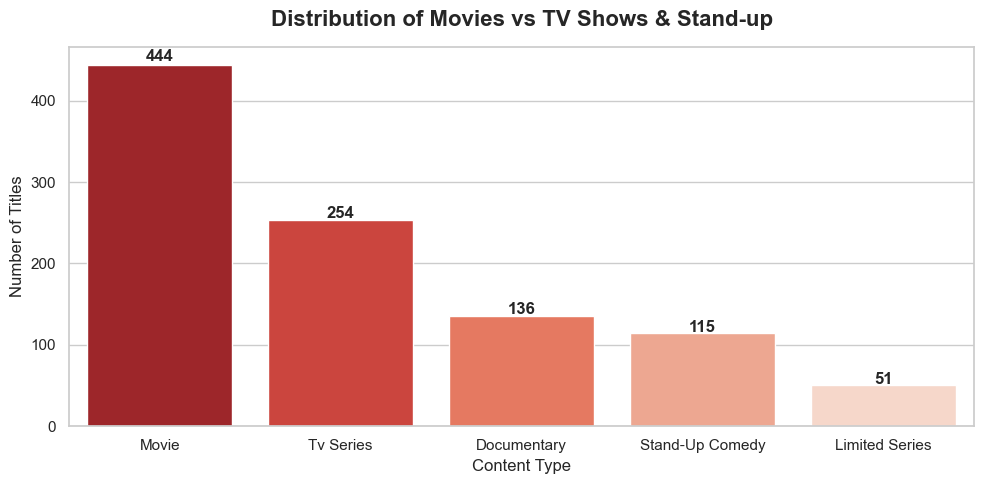

In [26]:
# Count the frequencies of each unique content type
content_counts = movies_clean['content_type'].value_counts()

# Plotting the distribution as a bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=content_counts.index, y=content_counts.values, palette="Reds_r")

# Customizing labels and titles for presentation
plt.title("Distribution of Movies vs TV Shows & Stand-up", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

# Adding data labels on top of each bar for clarity
for i, value in enumerate(content_counts.values):
    plt.text(i, value + (value * 0.01), f'{value:,}', ha='center', fontweight='bold')

plt.tight_layout()

# SAVE THE CHART: dpi=300 keeps the image crisp and high quality
plt.savefig('content_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\CA\AppData\Local\Temp\ipykernel_5460\186283768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


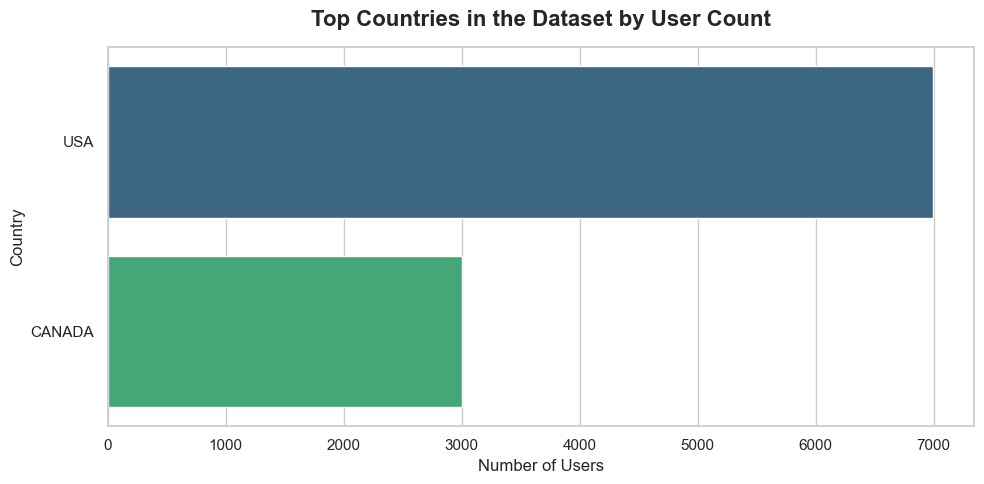

In [27]:
# Identify the top 10 countries represented in the dataset
top_countries = users_clean['country'].value_counts().head(10)

# Plotting a horizontal bar chart for enhanced readability
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")

# Formatting layout details
plt.title("Top Countries in the Dataset by User Count", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Users", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.tight_layout()

# SAVE THE CHART
plt.savefig('top_countries.png', dpi=300, bbox_inches='tight')
plt.show()

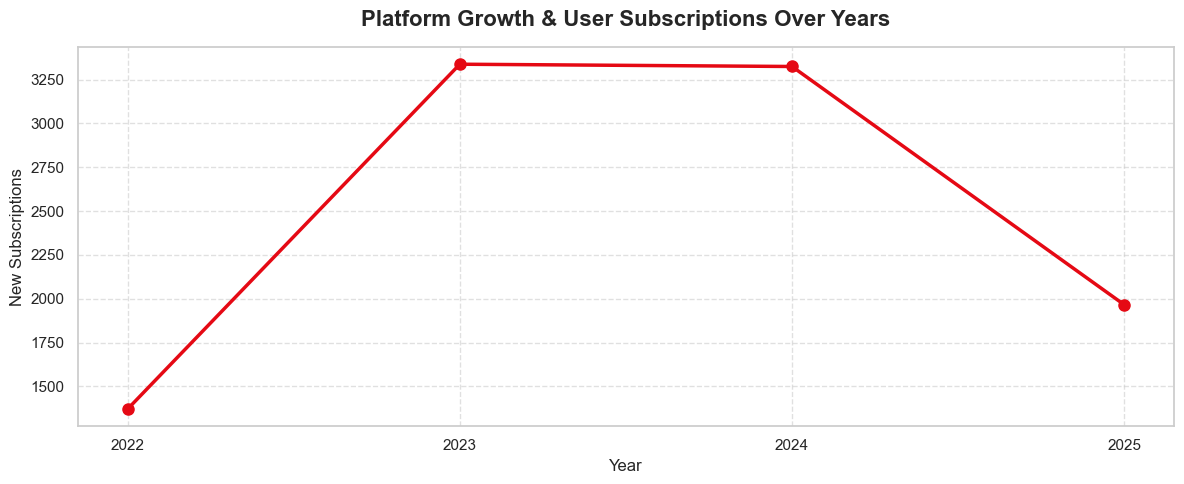

In [28]:
# Extract subscription year from datetime to track annual platform expansion
users_clean['join_year'] = users_clean['subscription_start_date'].dt.year
yearly_growth = users_clean['join_year'].value_counts().sort_index()

# Plotting the growth trend using a line chart
plt.figure(figsize=(12, 5))
plt.plot(yearly_growth.index, yearly_growth.values, marker='o', color='#E50914', linewidth=2.5, markersize=8)

# Styling and adjusting axis intervals
plt.title("Platform Growth & User Subscriptions Over Years", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("New Subscriptions", fontsize=12)
plt.xticks(yearly_growth.index)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# SAVE THE CHART
plt.savefig('platform_growth.png', dpi=300, bbox_inches='tight')
plt.show()

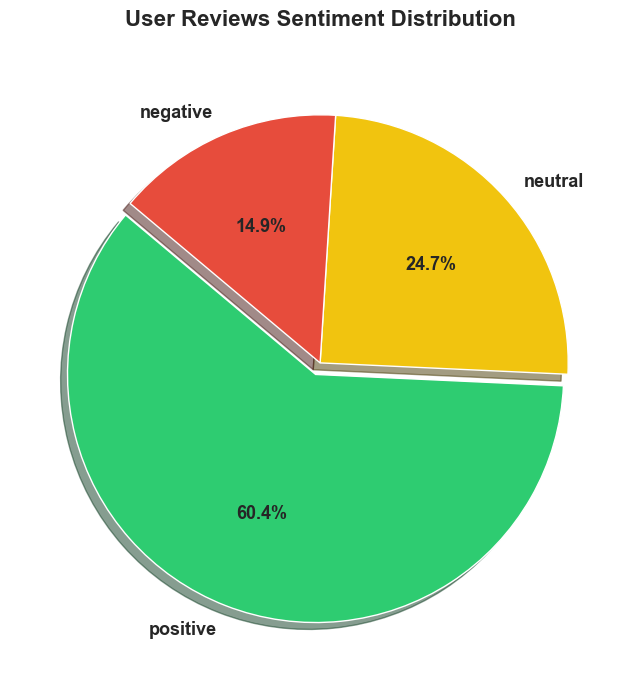

In [29]:
# Aggregate sentiment classifications to measure user satisfaction
sentiment_counts = reviews_clean['sentiment'].value_counts()

# Creating a pie chart to display proportion breakdown clearly
plt.figure(figsize=(7, 7))
explode_effect = [0.05 if i == 0 else 0 for i in range(len(sentiment_counts))]

plt.pie(sentiment_counts.values, 
        labels=sentiment_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#2ecc71', '#f1c40f', '#e74c3c'], # Green for positive, yellow for neutral, red for negative
        explode=explode_effect,
        shadow=True,
        textprops={'fontsize': 13, 'fontweight': 'bold'})

plt.title("User Reviews Sentiment Distribution", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

# SAVE THE CHART
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

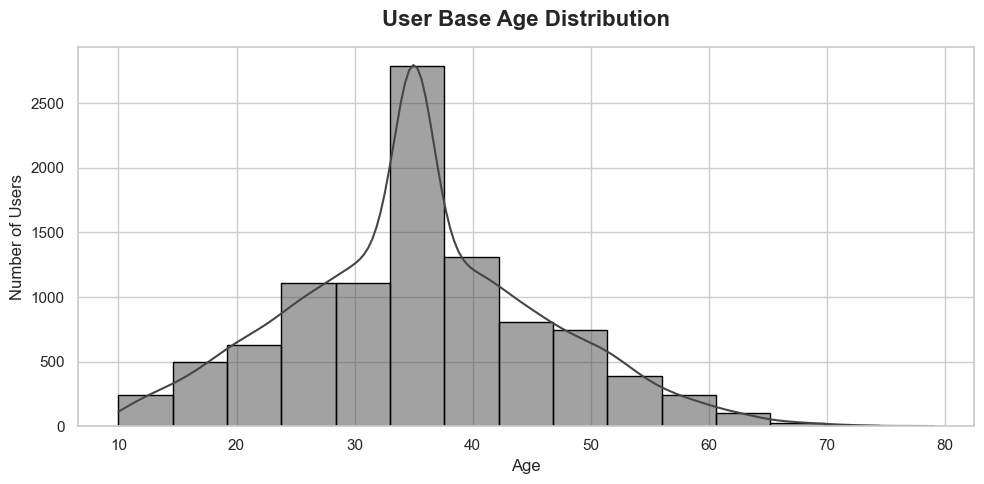

In [30]:
# Visualizing user age distribution using a histogram with Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 5))
sns.histplot(users_clean['age'], bins=15, kde=True, color='#464646', edgecolor='black')

# Setting labels and title properties
plt.title("User Base Age Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)

plt.tight_layout()

# SAVE THE CHART
plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\CA\AppData\Local\Temp\ipykernel_5460\3513950644.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=users_clean, x='country', y='monthly_spend', palette="Reds")


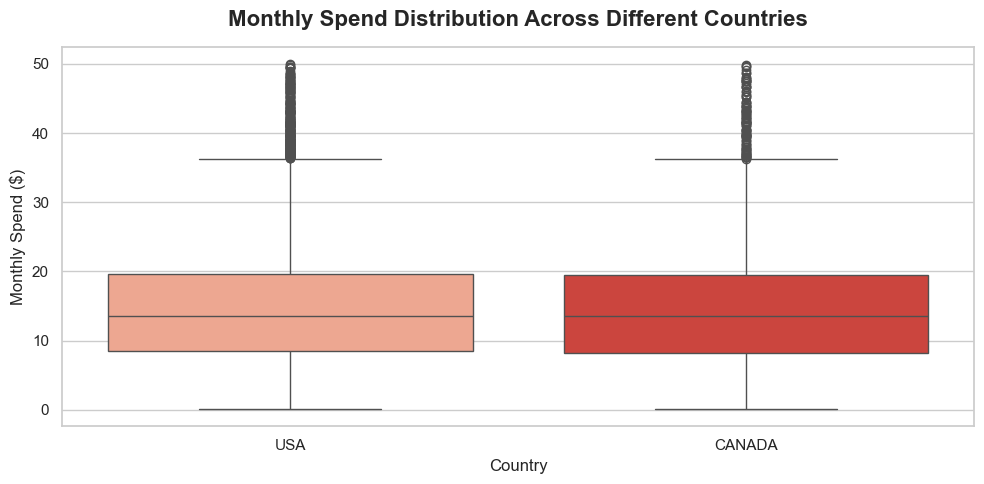

In [36]:
# Plotting the distribution of monthly spend across different countries using a boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=users_clean, x='country', y='monthly_spend', palette="Reds")

# Setting informative titles and labels for the presentation
plt.title("Monthly Spend Distribution Across Different Countries", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Monthly Spend ($)", fontsize=12)

plt.tight_layout()

# SAVE THE CHART: Saving with high resolution (300 DPI) for presentations
plt.savefig('spend_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\CA\AppData\Local\Temp\ipykernel_5460\143353098.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_duration = user_watch.groupby('age_group')['watch_duration_minutes'].mean().reset_index()
C:\Users\CA\AppData\Local\Temp\ipykernel_5460\143353098.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_duration, x='age_group', y='watch_duration_minutes', palette="dark:salmon_r")


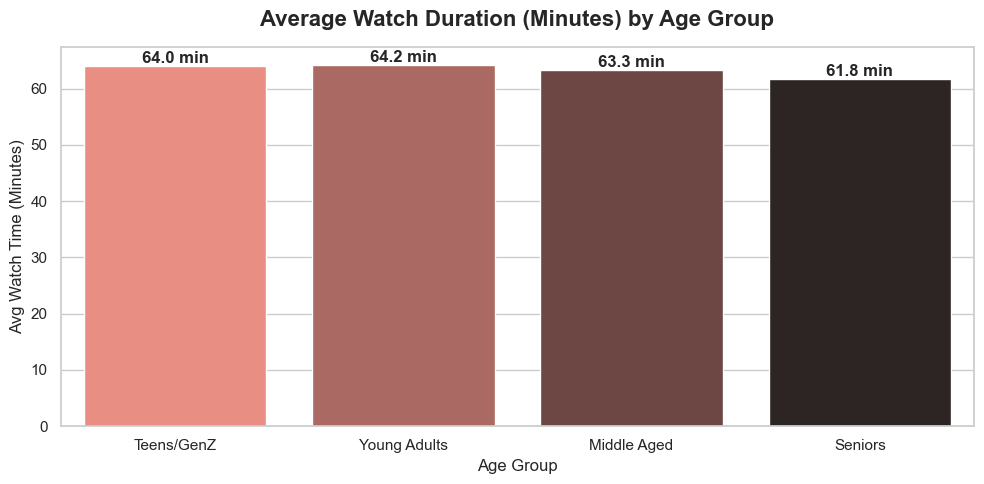

In [38]:
# Step 1: Merge users and watch history to combine demographic and behavior data
user_watch = pd.merge(watch_clean, users_clean, on='user_id', how='inner')

# Step 2: Bin the ages into standard demographic generational groups
user_watch['age_group'] = pd.cut(user_watch['age'], bins=[10, 25, 45, 65, 80], labels=['Teens/GenZ', 'Young Adults', 'Middle Aged', 'Seniors'])
age_duration = user_watch.groupby('age_group')['watch_duration_minutes'].mean().reset_index()

# Step 3: Plot the average watch time per age group
plt.figure(figsize=(10, 5))
sns.barplot(data=age_duration, x='age_group', y='watch_duration_minutes', palette="dark:salmon_r")

plt.title("Average Watch Duration (Minutes) by Age Group", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Avg Watch Time (Minutes)", fontsize=12)

# Append numerical values on top of the bars for quick ingestion
for i, value in enumerate(age_duration['watch_duration_minutes'].values):
    plt.text(i, value + 0.5, f'{value:.1f} min', ha='center', fontweight='bold')

plt.tight_layout()

# SAVE THE CHART
plt.savefig('watch_time_by_age.png', dpi=300, bbox_inches='tight')
plt.show()

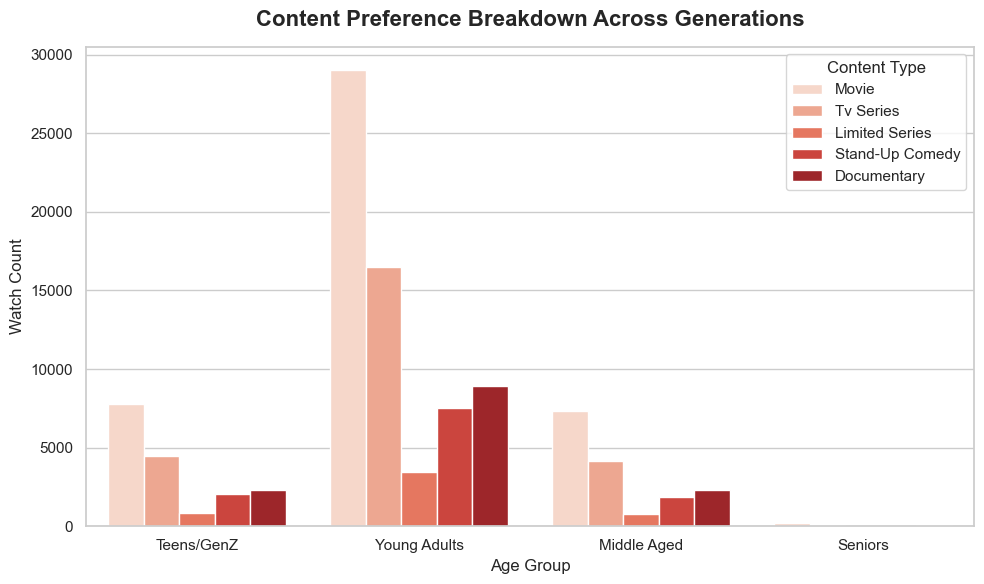

In [39]:
# Step 1: Merge user watch habits with movie profiles to fetch content_type data
watch_movies = pd.merge(user_watch, movies_clean, on='movie_id', how='inner')

# Step 2: Draw a grouped count plot to compare content preferences side by side
plt.figure(figsize=(10, 6))
sns.countplot(data=watch_movies, x='age_group', hue='content_type', palette="Reds")

plt.title("Content Preference Breakdown Across Generations", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Watch Count", fontsize=12)
plt.legend(title="Content Type", loc='upper right')

plt.tight_layout()

# SAVE THE CHART
plt.savefig('content_preference_by_age.png', dpi=300, bbox_inches='tight')
plt.show()